# Accra Urban Ground Deformation — Full InSAR Chain, Search to SBAS

Built entirely on the real, fixed pygeofetch InSAR pipeline — real orbit-based
coregistration, real AOI-aware cropped extraction, real atmospheric correction
with honest reporting, real SBAS inversion. Every cell here applies the fixes
found and verified against real Sentinel-1 data earlier in this project.

**Why Accra, not another vegetated site**: real InSAR coherence depends heavily
on land cover. Urban surfaces (concrete, asphalt, roofing) are stable radar
reflectors and typically maintain coherence in the 0.6-0.8 range, versus 0.2-0.4
for forest canopy — a genuine, well-established physical difference, not a
processing choice. This notebook targets that difference directly.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pygeofetch import PyGeoFetch
from pygeofetch.models.search_query import SearchQuery, BoundingBox
from pygeofetch.models.download_task import DownloadOptions
from pygeofetch.insar import (
    SLCExtractor, InterferogramGenerator, AtmosphericCorrector,
    PhaseUnwrapper, SBASTimeSeries, DataValidator, gpu_available,
    los_to_vertical_displacement, multilook,
)
from pygeofetch.insar.timeseries import InterferogramPair
from pygeofetch.insar.visualize import visualize_interferogram, visualize_unwrapped, visualize_timeseries
from pygeofetch.viz import Plotter, MapViewer
from pygeofetch.core.orbits import fetch_orbit_file

pl = Plotter(figsize=(12, 9))
print("Modules loaded")
print(f"GPU available in this environment: {gpu_available()} -- this notebook runs on CPU regardless (use_gpu=False set explicitly throughout)")

Modules loaded
GPU available in this environment: False -- this notebook runs on CPU regardless (use_gpu=False set explicitly throughout)


## 1. Study Area — Greater Accra Region (real boundary)

The real Greater Accra Region administrative boundary, 376 vertices, embedded
directly (not referenced as an external file, since this notebook needs to
run standalone on whatever machine actually executes it) — replacing the
earlier simplified rectangle with the actual region shape, the same real-
boundary-over-bbox upgrade made for the Obuasi district earlier in this
project. This is genuinely larger than the "~150 km² urban core" figure in
the original study brief, since it's the full real administrative region,
not just the CBD/Airport/Tema/East Legon sub-areas named as key points of
interest within it.

In [2]:
accra_boundary_coords = [
    [0.23456, 6.10986], [0.24774, 6.10573], [0.25411, 6.10001], [0.26629, 6.09566],
    [0.28144, 6.08390], [0.28698, 6.07732], [0.29051, 6.06224], [0.29546, 6.05734],
    [0.30090, 6.05479], [0.32351, 6.05253], [0.33783, 6.04724], [0.33677, 6.04178],
    [0.33197, 6.03789], [0.33175, 6.03396], [0.34223, 6.02807], [0.34865, 6.02221],
    [0.33981, 6.01920], [0.33183, 6.00740], [0.32970, 5.99669], [0.34084, 5.98920],
    [0.35069, 5.98827], [0.35333, 5.98665], [0.35042, 5.97852], [0.34803, 5.96244],
    [0.34387, 5.95396], [0.35280, 5.95483], [0.36640, 5.96045], [0.39458, 5.96081],
    [0.41606, 5.96954], [0.43430, 5.97403], [0.43867, 5.98132], [0.44110, 5.98275],
    [0.44103, 5.99504], [0.44465, 5.99722], [0.44605, 5.99651], [0.45005, 6.00163],
    [0.45355, 6.00159], [0.45850, 5.99826], [0.46741, 5.99836], [0.48070, 5.99068],
    [0.48370, 5.99254], [0.48596, 5.98985], [0.48473, 5.97554], [0.49196, 5.97971],
    [0.48978, 5.98422], [0.49083, 5.99557], [0.50124, 5.98959], [0.50552, 5.98974],
    [0.51302, 5.98362], [0.52535, 5.97888], [0.52402, 5.95494], [0.52767, 5.95264],
    [0.53643, 5.95312], [0.54170, 5.94976], [0.54526, 5.94346], [0.54735, 5.93508],
    [0.55039, 5.93513], [0.54852, 5.93175], [0.55078, 5.93149], [0.55176, 5.92906],
    [0.54792, 5.92499], [0.55099, 5.92035], [0.55270, 5.92572], [0.55513, 5.92709],
    [0.55901, 5.93936], [0.56101, 5.94015], [0.56607, 5.93821], [0.56953, 5.93234],
    [0.57156, 5.93277], [0.57063, 5.92990], [0.57201, 5.92952], [0.57604, 5.93289],
    [0.58165, 5.92779], [0.58875, 5.91873], [0.58540, 5.91826], [0.58733, 5.91346],
    [0.58046, 5.91013], [0.57455, 5.89991], [0.59491, 5.89032], [0.59970, 5.89062],
    [0.60547, 5.88400], [0.60678, 5.87693], [0.61906, 5.87581], [0.61383, 5.87476],
    [0.61241, 5.87289], [0.61275, 5.86766], [0.61498, 5.86464], [0.62851, 5.86800],
    [0.63150, 5.86684], [0.63047, 5.86260], [0.62840, 5.86430], [0.62592, 5.86306],
    [0.61972, 5.85401], [0.61994, 5.84566], [0.61869, 5.84321], [0.62028, 5.84075],
    [0.62028, 5.83431], [0.64270, 5.84104], [0.64615, 5.83816], [0.65457, 5.82730],
    [0.65185, 5.80527], [0.67813, 5.79486], [0.68796, 5.77782], [0.68632, 5.77494],
    [0.67974, 5.77489], [0.67611, 5.77740], [0.67596, 5.77521], [0.68015, 5.77084],
    [0.67705, 5.76869], [0.67005, 5.76858], [0.51534, 5.78491], [0.44311, 5.78914],
    [0.37913, 5.78707], [0.33237, 5.78353], [0.27648, 5.77316], [0.25276, 5.76638],
    [0.23948, 5.75602], [0.21915, 5.74642], [0.18464, 5.74338], [0.18214, 5.74169],
    [0.18280, 5.74010], [0.17393, 5.73854], [0.16357, 5.73167], [0.14079, 5.72369],
    [0.13214, 5.71584], [0.12969, 5.71013], [0.12406, 5.70679], [0.06726, 5.69315],
    [0.06110, 5.68529], [0.04515, 5.67517], [0.04300, 5.67170], [0.04420, 5.66968],
    [0.04347, 5.66351], [0.03345, 5.65762], [0.03193, 5.65421], [0.02810, 5.65160],
    [0.02721, 5.64537], [0.01722, 5.64237], [0.00414, 5.62446], [0.00012, 5.62469],
    [-0.01261, 5.62031], [-0.01554, 5.61739], [-0.02674, 5.61378], [-0.04264, 5.61168],
    [-0.05265, 5.60792], [-0.05742, 5.60809], [-0.05994, 5.60642], [-0.06269, 5.59898],
    [-0.06824, 5.59709], [-0.07358, 5.59009], [-0.09387, 5.58335], [-0.10226, 5.57500],
    [-0.10786, 5.57220], [-0.11474, 5.57039], [-0.12314, 5.56574], [-0.14767, 5.55962],
    [-0.16354, 5.55266], [-0.18132, 5.54814], [-0.18350, 5.54601], [-0.20251, 5.54209],
    [-0.20885, 5.53740], [-0.20970, 5.53430], [-0.20760, 5.53338], [-0.20845, 5.53285],
    [-0.29175, 5.51493], [-0.34453, 5.50201], [-0.35256, 5.49800], [-0.35842, 5.49769],
    [-0.40540, 5.47050], [-0.40668, 5.47813], [-0.40042, 5.48609], [-0.40246, 5.48691],
    [-0.40249, 5.49060], [-0.40443, 5.49175], [-0.40279, 5.49719], [-0.40500, 5.50299],
    [-0.40362, 5.50901], [-0.40552, 5.51159], [-0.40516, 5.51525], [-0.41334, 5.52495],
    [-0.41289, 5.52768], [-0.41602, 5.53770], [-0.41041, 5.55641], [-0.40450, 5.56207],
    [-0.40006, 5.56410], [-0.39998, 5.56594], [-0.40309, 5.57046], [-0.40608, 5.57187],
    [-0.40593, 5.57799], [-0.40907, 5.58298], [-0.41104, 5.58308], [-0.41401, 5.58778],
    [-0.41671, 5.58885], [-0.41818, 5.59483], [-0.42613, 5.60322], [-0.42705, 5.61009],
    [-0.42543, 5.61179], [-0.42746, 5.61386], [-0.42845, 5.61905], [-0.43242, 5.62192],
    [-0.43718, 5.62283], [-0.44649, 5.63096], [-0.45109, 5.63081], [-0.45776, 5.63679],
    [-0.46860, 5.64022], [-0.47961, 5.64655], [-0.48265, 5.64771], [-0.49458, 5.64475],
    [-0.49715, 5.64668], [-0.49767, 5.64901], [-0.49368, 5.65434], [-0.49525, 5.65964],
    [-0.49840, 5.66272], [-0.49974, 5.66829], [-0.50339, 5.67147], [-0.50483, 5.67695],
    [-0.50920, 5.68314], [-0.51602, 5.68680], [-0.51847, 5.68645], [-0.52007, 5.69587],
    [-0.51897, 5.69966], [-0.52058, 5.70217], [-0.51996, 5.70539], [-0.51596, 5.70683],
    [-0.50829, 5.71370], [-0.50918, 5.72209], [-0.51184, 5.72672], [-0.50923, 5.73287],
    [-0.51133, 5.73426], [-0.51034, 5.73623], [-0.50882, 5.73564], [-0.49542, 5.74734],
    [-0.49220, 5.74684], [-0.49241, 5.75122], [-0.49052, 5.75425], [-0.47435, 5.76091],
    [-0.46432, 5.76742], [-0.45961, 5.76812], [-0.46044, 5.76981], [-0.45877, 5.77200],
    [-0.45160, 5.77480], [-0.44851, 5.77805], [-0.44395, 5.77749], [-0.44793, 5.78993],
    [-0.43745, 5.80086], [-0.42826, 5.79276], [-0.42432, 5.79353], [-0.42236, 5.78945],
    [-0.41570, 5.78760], [-0.41486, 5.78230], [-0.41622, 5.77732], [-0.41209, 5.77126],
    [-0.40278, 5.76728], [-0.39395, 5.75913], [-0.39010, 5.75796], [-0.38888, 5.76749],
    [-0.38475, 5.77638], [-0.37898, 5.77458], [-0.37845, 5.77021], [-0.37092, 5.76733],
    [-0.36639, 5.76241], [-0.35468, 5.76708], [-0.35231, 5.76632], [-0.34917, 5.77335],
    [-0.34237, 5.77768], [-0.33776, 5.77816], [-0.33540, 5.77661], [-0.33147, 5.77892],
    [-0.32743, 5.77254], [-0.32462, 5.77445], [-0.32201, 5.77961], [-0.31558, 5.78030],
    [-0.31642, 5.78272], [-0.31064, 5.78934], [-0.28282, 5.80233], [-0.27465, 5.80800],
    [-0.27070, 5.80826], [-0.26928, 5.80474], [-0.26550, 5.80769], [-0.26496, 5.80347],
    [-0.26366, 5.80350], [-0.26073, 5.79547], [-0.25993, 5.78513], [-0.25652, 5.77791],
    [-0.24471, 5.78523], [-0.23338, 5.78440], [-0.23515, 5.78054], [-0.23541, 5.77292],
    [-0.24252, 5.76258], [-0.24369, 5.75770], [-0.23234, 5.75504], [-0.22660, 5.75198],
    [-0.22730, 5.74214], [-0.22506, 5.74007], [-0.22134, 5.74289], [-0.22046, 5.74844],
    [-0.21805, 5.75076], [-0.21452, 5.74968], [-0.20726, 5.75463], [-0.20194, 5.76315],
    [-0.20445, 5.76368], [-0.20487, 5.76870], [-0.20256, 5.78195], [-0.19838, 5.78451],
    [-0.19418, 5.78418], [-0.18058, 5.79441], [-0.17797, 5.79987], [-0.17232, 5.80509],
    [-0.17233, 5.81401], [-0.16588, 5.81209], [-0.15504, 5.81473], [-0.15282, 5.82698],
    [-0.14928, 5.83047], [-0.14927, 5.83372], [-0.15292, 5.83981], [-0.16398, 5.83828],
    [-0.16396, 5.84170], [-0.15581, 5.84621], [-0.15398, 5.84974], [-0.14655, 5.85218],
    [-0.14393, 5.85492], [-0.13767, 5.85117], [-0.12988, 5.85288], [-0.13002, 5.85939],
    [-0.12821, 5.86108], [-0.12872, 5.86440], [-0.12683, 5.86820], [-0.12688, 5.87546],
    [-0.12289, 5.87972], [-0.09547, 5.90119], [-0.08372, 5.90702], [-0.06396, 5.92758],
    [-0.06095, 5.93298], [-0.04651, 5.94276], [-0.04091, 5.94395], [-0.02037, 5.96121],
    [-0.01913, 5.96040], [-0.01642, 5.96192], [-0.01219, 5.96752], [-0.00630, 5.97117],
    [-0.00439, 5.97634], [-0.00464, 5.98566], [-0.00815, 5.99343], [-0.01481, 5.99721],
    [-0.01373, 6.00134], [-0.00961, 6.01038], [-0.00081, 6.00771], [0.00380, 6.00931],
    [0.00577, 6.01205], [0.00850, 6.01832], [0.00837, 6.02427], [0.01352, 6.02997],
    [0.01600, 6.03700], [0.01818, 6.03887], [0.01900, 6.06187], [0.02690, 6.05828],
    [0.04036, 6.04790], [0.06255, 6.05974], [0.08978, 6.06287], [0.10448, 6.07780],
    [0.11285, 6.08233], [0.11792, 6.08329], [0.12240, 6.08770], [0.14362, 6.10078],
    [0.14447, 6.10597], [0.14681, 6.10917], [0.19092, 6.09685], [0.20865, 6.10417],
    [0.21289, 6.10272], [0.21407, 6.10441], [0.22424, 6.10511], [0.23302, 6.10804],
    [0.23226, 6.10977], [0.23065, 6.10926], [0.22892, 6.11012], [0.23456, 6.10986],
]

accra_geometry = {"type": "Polygon", "coordinates": [accra_boundary_coords]}

accra_lons = [c[0] for c in accra_boundary_coords]
accra_lats = [c[1] for c in accra_boundary_coords]
aoi_bbox = BoundingBox(
    min_lon=min(accra_lons), max_lon=max(accra_lons),
    min_lat=min(accra_lats), max_lat=max(accra_lats),
)
aoi_extent = (aoi_bbox.min_lon, aoi_bbox.max_lon, aoi_bbox.min_lat, aoi_bbox.max_lat)

output_dir = Path("./data/accra_insar")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Study area: Greater Accra Region, {len(accra_boundary_coords)-1} real boundary vertices")
print(f"Bounding extent: {aoi_extent}")

Study area: Greater Accra Region, 375 real boundary vertices
Bounding extent: (-0.52058, 0.68796, 5.4705, 6.11012)


## 2. Search — Sentinel-1 SLC (not GRD)

Real date windows, same 12-day repeat cadence used for the Obuasi run —
confirmed available real S1A data with real, published precise orbit files
for this exact period (past the ~21-day POEORB publication lag).

Uses `geometry=` with the real region polygon (the field that actually
constrains the search to the real shape, not just its bounding rectangle) —
not `geometry_geojson=`, a declared-but-unused field on SearchQuery that
silently applies no spatial filter at all (the real bug that cost the
Obuasi run a full 47GB of wrong-location downloads earlier in this project).

In [3]:
client = PyGeoFetch(log_level="INFO")
client.add_credentials("copernicus", username="appiahkubis14@gmail.com", password="CDSE@sak@19999eocoreint")

search_windows = [
    ("2024-11-01", "2024-11-08"), ("2024-11-13", "2024-11-20"),
    ("2024-11-25", "2024-12-02"), ("2024-12-07", "2024-12-14"),
    ("2024-12-19", "2024-12-26"), ("2025-01-01", "2025-01-08"),
]

scenes = {}
for start, end in search_windows:
    query = SearchQuery(
        geometry=accra_geometry, start_date=start, end_date=end,
        product_type="SLC", polarisation="VV", max_results=5,
    )
    results = client.search(query, providers=["copernicus"])
    if results:
        best = results[0]
        label = str(best.datetime.date()) if best.datetime else start
        scenes[label] = best
        print(f"  {start[:10]}: {best.id} ({label})")
    else:
        print(f"  {start[:10]}: no SLC scenes found")

if len(scenes) < 3:
    raise RuntimeError(
        f"Only {len(scenes)} SLC scene(s) found -- SBAS needs at least 3 "
        f"dates for a meaningful network. Widen the search windows and "
        f"try again. No synthetic fallback is used."
    )
print(f"\n{len(scenes)} dates found -- proceeding with real SLC data only.")

10:48:39 INFO [      engine] PyGeoFetch ready
10:48:39 INFO [authenticator] Credentials saved for provider 'copernicus'
┌ SEARCH PARAMETERS ───────────────────────────────────────────────────────┐
│ Providers  : copernicus                                                  │
│ BBox       : —                                                           │
│ Date range : 2024-11-01  →  2024-11-08                                   │
│ Cloud max  : 100%                                                        │
│ Product    : SLC                                                         │
└──────────────────────────────────────────────────────────────────────────┘
10:48:40 INFO [  copernicus] Authenticated with Copernicus Data Space as 'appiahkubis14@gmail.com'
  ✓  copernicus                       1 scenes   2.8s
┌────────────────────────────────────────────┬────────────┬────────────────┬────────┬─────────┬──────────────┬─────────────┬───────┬───────┬──────────────────────┐
│                  SCENE

## 3. Download

In [4]:
download_options = DownloadOptions(parallel=1, resume=True, on_failure="skip")
download_results = {}

for label, scene in scenes.items():
    dl_dir = output_dir / "raw" / label
    result = client.download([scene], destination=dl_dir, options=download_options)[0]
    if result.success:
        download_results[label] = result
        print(f"  {label}: OK")
    else:
        print(f"  {label}: FAILED -- {result.error}")

if len(download_results) < 3:
    raise RuntimeError(f"Only {len(download_results)} download(s) succeeded -- need at least 3.")

⬇ 1 scene  →  data/accra_insar/raw/2024-11-03              0/1  [00:00]

7d113ef7-9055-4f1b-bfe7-c664437008cd: 0.00B [00:00, ?B/s]

10:49:04 INFO [  downloader]   ↷ 7d113ef7-9055-4f1b-bfe7-c664437008cd          already downloaded, skipping (resume=True)
  2024-11-03: OK


⬇ 1 scene  →  data/accra_insar/raw/2024-11-15              0/1  [00:00]

b6763563-aa42-4e70-aa1f-b0f288cbcd66: 0.00B [00:00, ?B/s]

...

64a32d9f-e761-45a7-b2cc-c28843859457: 0.00B [00:00, ?B/s]

10:49:50 INFO [  downloader]   ↷ 64a32d9f-e761-45a7-b2cc-c28843859457          already downloaded, skipping (resume=True)
  2024-12-21: OK


⬇ 1 scene  →  data/accra_insar/raw/2025-01-02              0/1  [00:00]

53092b6d-08c7-4c9e-9408-dd7091f40662: 0.00B [00:00, ?B/s]

10:50:01 INFO [  downloader]   ↷ 53092b6d-08c7-4c9e-9408-dd7091f40662          already downloaded, skipping (resume=True)
  2025-01-02: OK


## 4. Get a real DEM — needed for topographic phase removal and real coregistration

In [5]:
from pygeofetch.processing.preprocessor import Preprocessor

client.add_credentials("opentopography", api_key="b0d75bfc54e0d7e7d398381bbe3c5e94")

dem_query = SearchQuery(bbox=aoi_bbox, max_results=10)
dem_results = client.search(dem_query, providers=["opentopography"])

cop30_result = next((r for r in dem_results if r.properties.get("product") == "cop30"), None)
if cop30_result is None:
    raise RuntimeError("Copernicus DEM (30m) not found -- cannot proceed without a real DEM.")

dem_dl_result = client.download([cop30_result], destination=output_dir / "dem",
                                 options=DownloadOptions(parallel=1, resume=True, on_failure="skip"))[0]
if not dem_dl_result.success:
    raise RuntimeError(f"DEM download failed: {dem_dl_result.error}")


10:50:49 INFO [authenticator] Credentials saved for provider 'opentopography'
┌ SEARCH PARAMETERS ───────────────────────────────────────────────────────┐
│ Providers  : opentopography                                              │
│ BBox       : [-0.521, 5.471, 0.688, 6.110]                               │
│ Date range : None  →  None                                               │
│ Cloud max  : 100%                                                        │
│ Product    : any                                                         │
└──────────────────────────────────────────────────────────────────────────┘
  ✓  opentopography                   7 scenes   0.0s
┌────────────────────────────────────────────┬────────────┬────────────────┬────────┬─────────┬──────────────┬─────────────┬───────┬───────┬──────────────────────┐
│                  SCENE ID                  │    DATE    │   SATELLITE    │ CLOUD  │ PRODUCT │ POLARISATION │    PASS     │ ORBIT │ SCORE │       PROVIDER       │
├

⬇ 1 scene  →  data/accra_insar/dem              0/1  [00:00]

opentopo_COP30_-0.52058_5.4705: 0.00B [00:00, ?B/s]

10:50:50 INFO [  downloader]   ↷ opentopo_COP30_-0.52058_5.4705                already downloaded, skipping (resume=True)


In [6]:
pp_dem = Preprocessor()
dem_clip_result = pp_dem.clip(
    dem_dl_result.output_path,
    geometry=accra_geometry,  # the real region shape, not its bounding rectangle
    output=str(output_dir / "dem" / "accra_dem_clipped.tif"),
)
if not dem_clip_result.success:
    raise RuntimeError(f"DEM clip failed: {dem_clip_result.error}")

dem_path = dem_clip_result.output_path
print(f"Real DEM ready: {dem_path}")

10:50:53 INFO [preprocessor] Clipped → data/accra_insar/dem/accra_dem_clipped.tif
Real DEM ready: data/accra_insar/dem/accra_dem_clipped.tif


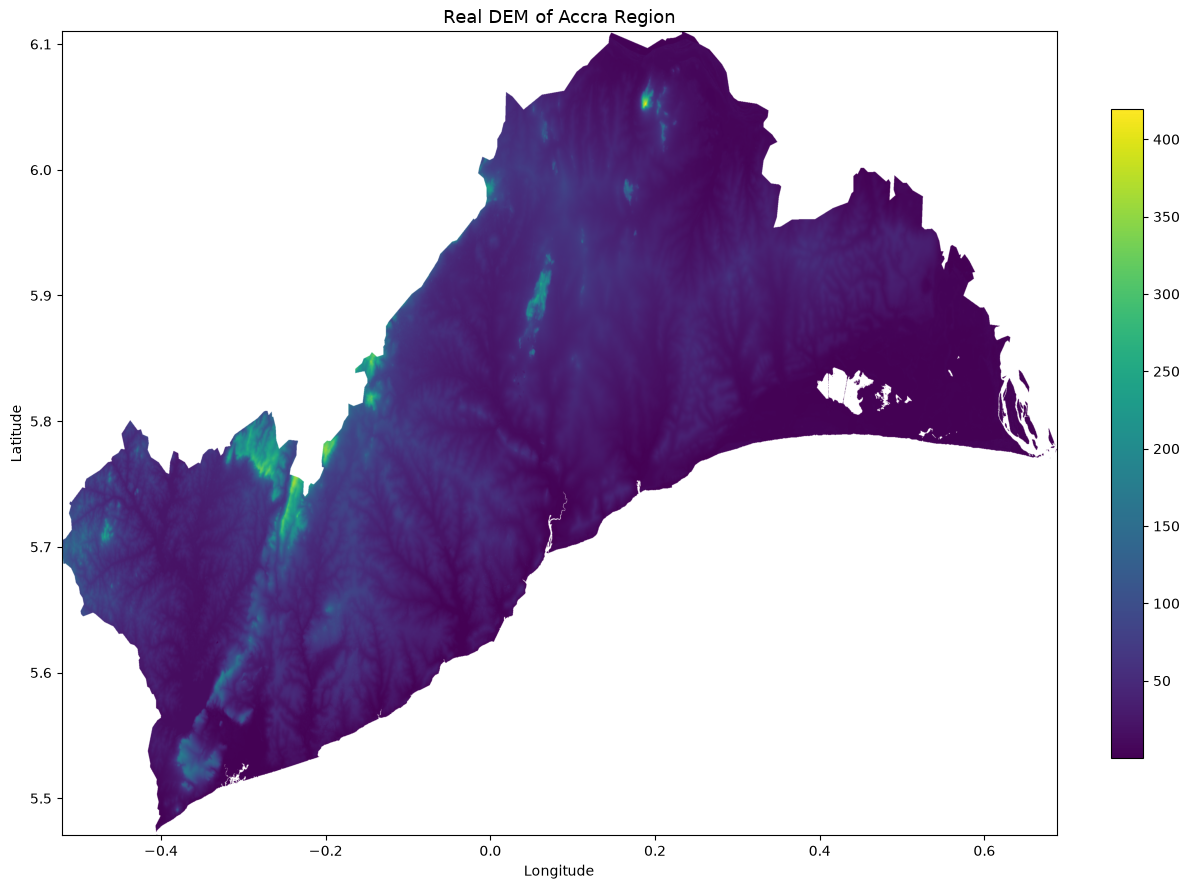

In [7]:
pl.plot_raster(
    dem_path, title=f"Real DEM of Accra Region",
    colormap="viridis",
    # output=str(output_dir / "slc" / f"{first_date}_amplitude.png"),
)
pl._save_or_show(fig=None,output='' )

## 5. Fetch real orbit files — for real orbit-based coregistration

Uses `scene.properties.get("name", scene.id)` — the real Sentinel-1 product
name, not the Copernicus catalog UUID. `fetch_orbit_file()` needs the
acquisition datetime embedded in the real product name to work; the UUID
alone has no parseable date at all (a real bug found and fixed during the
Obuasi run: passing `scene.id` directly produced "Cannot parse acquisition
datetime" on every single date).

In [8]:
orbit_files = {}
orbit_dir = output_dir / "orbits"
for label, scene in scenes.items():
    product_name = scene.properties.get("name", scene.id)
    path = fetch_orbit_file(product_name=product_name, output_dir=str(orbit_dir), orbit_type="precise")
    if path is None:
        print(f"  {label}: no precise orbit file available yet (pair(s) using this date will")
        print(f"           fall back to shape-based coregistration automatically)")
    else:
        orbit_files[label] = path
        print(f"  {label}: {Path(path).name}")

print(f"\n{len(orbit_files)}/{len(scenes)} real orbit files available")

10:51:00 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20241123T070558_V20241102T225942_20241104T005942.EOF
  2024-11-03: S1A_OPER_AUX_POEORB_OPOD_20241123T070558_V20241102T225942_20241104T005942.EOF
10:51:00 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20241205T070604_V20241114T225942_20241116T005942.EOF
  2024-11-15: S1A_OPER_AUX_POEORB_OPOD_20241205T070604_V20241114T225942_20241116T005942.EOF
10:51:00 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20241217T070615_V20241126T225942_20241128T005942.EOF
  2024-11-27: S1A_OPER_AUX_POEORB_OPOD_20241217T070615_V20241126T225942_20241128T005942.EOF
10:51:00 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20241229T070554_V20241208T225942_20241210T005942.EOF
  2024-12-09: S1A_OPER_AUX_POEORB_OPOD_20241229T070554_V20241208T225942_20241210T005942.EOF
10:51:00 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20250110T070616_V20241220

## 6. SLC extraction — AOI-cropped, not the full sub-swath

Uses the real, fixed `extract_scene()` — reads directly from inside the zip
(no full-file extraction), fits a real affine transform from the embedded
GCPs, and crops to the AOI with a safety margin. Verified during the Obuasi
run to produce a ~49x size reduction versus the old raw full-sub-swath copy,
with correctness confirmed against a known marker at a known location before
ever trusting it on real data.

In [9]:
slc_extractor = SLCExtractor(polarisation="VV")
extracted_slcs = {}

for label, result in download_results.items():
    slc_dir = output_dir / "slc" / label
    path = slc_extractor.extract_scene(result.output_path, aoi=aoi_bbox, output_dir=slc_dir, label=label)
    if path is not None:
        extracted_slcs[label] = path
        print(f"  {label}: extracted -> {path.name}")
    else:
        print(f"  {label}: no matching sub-swath found for this AOI")

if len(extracted_slcs) < 3:
    raise RuntimeError(f"Only {len(extracted_slcs)} SLC(s) extracted -- need at least 3.")
extracted_dates = sorted(extracted_slcs.keys())
print(f"\n{len(extracted_slcs)} SLCs extracted: {extracted_dates}")

10:51:03 INFO [  extraction] Found 3 VV sub-swath(s) in S1A_IW_SLC__1SDV_20241103T181824_20241103T181854_056394_06E8D5_68BD.SAFE.zip
10:52:05 INFO [  extraction] Cropped IW2: 24629x14990 -> 17982x9917 (2.1x smaller)
10:52:05 INFO [  extraction] Extracted IW2 -> 2024-11-03_vv.tif
  2024-11-03: extracted -> 2024-11-03_vv.tif
10:52:05 INFO [  extraction] Found 3 VV sub-swath(s) in S1A_IW_SLC__1SDV_20241115T181823_20241115T181853_056569_06EFCE_F666.SAFE.zip
10:53:13 INFO [  extraction] Cropped IW2: 24627x14990 -> 17984x9915 (2.1x smaller)
10:53:13 INFO [  extraction] Extracted IW2 -> 2024-11-15_vv.tif
  2024-11-15: extracted -> 2024-11-15_vv.tif
10:53:13 INFO [  extraction] Found 3 VV sub-swath(s) in S1A_IW_SLC__1SDV_20241127T181822_20241127T181852_056744_06F6CD_C986.SAFE.zip
10:54:14 INFO [  extraction] Cropped IW2: 24627x14990 -> 18009x9916 (2.1x smaller)
10:54:14 INFO [  extraction] Extracted IW2 -> 2024-11-27_vv.tif
  2024-11-27: extracted -> 2024-11-27_vv.tif
10:54:14 INFO [  extracti

### 6b. Visualize the extracted amplitude — real urban texture expected

In [ ]:
import rasterio

first_date = extracted_dates[0]
with rasterio.open(extracted_slcs[first_date]) as src:
    slc_sample = src.read(1)
    print(f"Size: {src.height} x {src.width} ({src.height*src.width/1e6:.2f} million pixels)")

amplitude_db = 20 * np.log10(np.abs(slc_sample) + 1e-10)
pl.plot_raster(
    amplitude_db, title=f"Extracted SLC Amplitude — Accra {first_date}",
    colormap="gray", colorbar_label="Amplitude (dB)",
)
print(f"Amplitude range: [{np.percentile(amplitude_db, 2):.1f}, {np.percentile(amplitude_db, 98):.1f}] dB (2nd-98th percentile)")
print("Real urban texture should look visually different from Obuasi's forest speckle --")
print("more structured, brighter linear features (roads, building edges, corner reflectors).")

Size: 9917 x 17982 (178.33 million pixels)
Amplitude range: [7.0, 48.0] dB (2nd-98th percentile)
Real urban texture should look visually different from Obuasi's forest speckle --
more structured, brighter linear features (roads, building edges, corner reflectors).


## 7. Interferogram formation — real orbit-based coregistration from the start

All four real coregistration inputs (both SAFE zips, both orbit files) are
wired in from the first run, not added after discovering shape-based
fallback wasn't enough — the lesson from the Obuasi session's own debugging
history. Falls back cleanly to shape-based resampling for any date pair
missing an orbit file, with a clear log line either way.

In [ ]:
ifg_gen = InterferogramGenerator(coherence_window=5, esd_enabled=True, use_gpu=False)
interferograms = {}

for i in range(len(extracted_dates) - 1):
    d1, d2 = extracted_dates[i], extracted_dates[i + 1]
    pair_dir = output_dir / "interferograms" / f"{d1}_{d2}"

    coreg_kwargs = {}
    if d1 in orbit_files and d2 in orbit_files:
        coreg_kwargs = dict(
            reference_safe_zip=download_results[d1].output_path,
            secondary_safe_zip=download_results[d2].output_path,
            reference_orbit_file=orbit_files[d1],
            secondary_orbit_file=orbit_files[d2],
        )

    try:
        result = ifg_gen.process_pair(
            reference=extracted_slcs[d1], secondary=extracted_slcs[d2],
            dem=dem_path, reference_date=d1, secondary_date=d2,
            **coreg_kwargs,
        )
    except ValueError as exc:
        print(f"  {d1} -> {d2}: REJECTED by DataValidator -- {exc}")
        continue

    result.save(pair_dir, auto_visualize=True)
    interferograms[(d1, d2)] = result
    print(f"  {d1} -> {d2}: OK, mean coherence {np.mean(result.coherence):.3f}")

if len(interferograms) < 2:
    raise RuntimeError(f"Only {len(interferograms)} interferogram(s) formed -- need at least 2 for SBAS.")

coherences = [np.mean(r.coherence) for r in interferograms.values()]
print(f"\nCoherence summary: mean={np.mean(coherences):.3f}, range=[{min(coherences):.3f}, {max(coherences):.3f}]")
print("Compare directly against the Obuasi run's 0.27-0.28: urban surfaces should show a real,")
print("substantial improvement if the land-cover hypothesis holds -- this is the actual test.")

05:19:23 INFO [  annotation] Parsed real SLC geometry from S1A_IW_SLC__1SDV_20241103T181824_20241103T181854_056394_06E8D5_68BD.SAFE.zip: 14990 x 24629, starting 2024-11-03 18:18:25.262628
05:19:23 INFO [  annotation] Parsed real SLC geometry from S1A_IW_SLC__1SDV_20241115T181823_20241115T181853_056569_06EFCE_F666.SAFE.zip: 14990 x 24627, starting 2024-11-15 18:18:24.811545
05:19:23 INFO [ geolocation] Parsed 9361 orbit state vectors from S1A_OPER_AUX_POEORB_OPOD_20241123T070558_V20241102T225942_20241104T005942.EOF
05:19:24 INFO [ geolocation] Parsed 9361 orbit state vectors from S1A_OPER_AUX_POEORB_OPOD_20241205T070604_V20241114T225942_20241116T005942.EOF
05:19:25 INFO [  coregister] DEM-driven offset field: 14/49 points solved successfully
05:19:25 INFO [interferogram] Correcting for cropped extraction: reference offset (1111, 6647), secondary offset (1109, 6643)
05:19:25 INFO [interferogram] Real orbit-based coregistration applied (14 grid points)


## 8. Atmospheric correction — with honest, real reporting

Uses `return_metadata=True` and branches on `correction_applied`, not an
unconditional print — the real bug found and fixed during the Obuasi run,
where the log correctly said "skipping" while the print statement
unconditionally claimed "applied", a genuine contradiction traced back
to `AtmosphericCorrector.correct()` never telling callers which outcome
actually happened.

In [ ]:
atm_corrector = AtmosphericCorrector(method="elevation")
corrected_interferograms = {}
atm_metadata = {}

if dem_path is not None:
    for (d1, d2), result in interferograms.items():
        wrapped_phase = np.angle(result.interferogram)
        corrected_phase, atm_meta = atm_corrector.correct(
            wrapped_phase, dem=dem_path, return_metadata=True
        )
        corrected_interferograms[(d1, d2)] = corrected_phase
        atm_metadata[(d1, d2)] = atm_meta

        r2 = atm_meta.get("r_squared")
        if atm_meta["correction_applied"]:
            print(f"  {d1} -> {d2}: atmospheric correction applied (R2={r2:.2f})")
        else:
            print(f"  {d1} -> {d2}: atmospheric correction skipped (R2 = {r2!r}, too weak to trust)")
else:
    print("No DEM supplied -- skipping atmospheric correction and using raw wrapped phase directly.")
    corrected_interferograms = {k: np.angle(v.interferogram) for k, v in interferograms.items()}

## 9. Phase unwrapping — SNAPHU

Starts with a real, standard multilook (4 azimuth x 1 range = 4 looks) —
much lighter than the 100-look averaging the Obuasi run needed, since urban
coherence should already be high enough that heavy averaging isn't required
to reach reliable unwrapping. This is checked directly below, not assumed:
if reliable coverage comes back low despite the expected high coherence,
that's real, actionable information worth stopping on, not pushing past.

Uses the real `multilook()` now built into pygeofetch itself, not a
notebook-local copy — including a real fix found while embedding it: the
original notebook version guessed circular-vs-arithmetic averaging from
dtype alone, which cannot actually distinguish wrapped phase (needs
circular averaging) from coherence or unwrapped phase (needs plain
arithmetic averaging). Confirmed directly that guessing wrong on real
unwrapped phase silently collapses a ~45 rad value down to ~1.3 rad. The
real library version requires `wrapped_phase=` explicitly rather than
guessing.

In [ ]:
unwrapper = PhaseUnwrapper(cost_mode="defo", init_method="mcf")
unwrapped_results = {}
LOOKS_AZ, LOOKS_RG = 4, 1

reliability_summary = {}
for (d1, d2), phase in corrected_interferograms.items():
    coherence = interferograms[(d1, d2)].coherence
    phase_ml = multilook(phase, LOOKS_AZ, LOOKS_RG, wrapped_phase=True)
    coherence_ml = multilook(coherence, LOOKS_AZ, LOOKS_RG, wrapped_phase=False)

    unwrapped, conncomp = unwrapper.unwrap(phase_ml, coherence_ml, nlooks=float(LOOKS_AZ * LOOKS_RG))
    unwrapped_results[(d1, d2)] = unwrapped

    reliable_pct = 100 * np.mean(conncomp > 0)
    reliability_summary[(d1, d2)] = reliable_pct
    print(f"  {d1} -> {d2}: reliable={reliable_pct:5.1f}%  mean_coherence={np.mean(coherence_ml):.3f}  "
          f"range=[{np.nanmin(unwrapped):.2f}, {np.nanmax(unwrapped):.2f}] rad")

mean_reliability = np.mean(list(reliability_summary.values()))
print(f"\nMean reliable coverage across all pairs: {mean_reliability:.1f}%")
if mean_reliability < 10:
    print("\nLOW -- if this happens despite urban land cover, do NOT assume the same fix as")
    print("Obuasi (aggressive ~100-look averaging) will work the same way here -- check the")
    print("actual coherence histogram and spatial map first, the same diagnostic discipline")
    print("used throughout the Obuasi debugging, before choosing a next step.")

## 10. SBAS network assembly and connectivity check

Uses `DataValidator.validate_sbas_network()`, wired into the real pipeline
(not dead code) — checks the network is actually connected before the
expensive inversion runs.

In [ ]:
sbas_pairs = []
for (d1, d2), unwrapped in unwrapped_results.items():
    coherence_ml = multilook(interferograms[(d1, d2)].coherence, LOOKS_AZ, LOOKS_RG, wrapped_phase=False)
    sbas_pairs.append(InterferogramPair(
        reference_date=d1, secondary_date=d2,
        unwrapped_phase=unwrapped.astype(np.float32),
        coherence=coherence_ml.astype(np.float32),
    ))

network_check = DataValidator.validate_sbas_network(sbas_pairs, extracted_dates)
if not network_check.valid:
    print(f"Network validation FAILED: {network_check.errors}")
else:
    print(f"Network validated: {len(sbas_pairs)} pairs across {len(extracted_dates)} dates, fully connected")

## 11. SBAS inversion — displacement time series

In [ ]:
sbas = SBASTimeSeries(reference_date=extracted_dates[0], use_gpu=False)
ts_result = sbas.invert(sbas_pairs, coherence_threshold=0.3)

velocity_mm_yr = ts_result.velocity * 1000
print(f"Velocity range: [{np.nanmin(velocity_mm_yr):.1f}, {np.nanmax(velocity_mm_yr):.1f}] mm/year")
print(f"Mean residual RMS: {np.nanmean(ts_result.residual_rms):.4f} rad")

ts_dir = output_dir / "timeseries"
ts_result.save(ts_dir, auto_visualize=True)

pl.plot_raster(
    velocity_mm_yr, title="Accra — LOS Velocity",
    colormap="RdBu_r", vmin=-30, vmax=30,
    colorbar_label="LOS velocity (mm/year)",
    output=str(ts_dir / "velocity_map.png"),
)

## 12. LOS-to-vertical conversion

Same honest, assumption-labeled technique used for Obuasi — real for
vertically-dominated deformation (subsidence from groundwater extraction
or construction loading, both named as real candidate causes in the study
rationale), not automatically valid for lateral movement.

In [ ]:
INCIDENCE_ANGLE_DEG = 39.0
vertical_velocity_mm_yr = los_to_vertical_displacement(
    ts_result.velocity, incidence_angle_deg=INCIDENCE_ANGLE_DEG
) * 1000

print(f"Vertical-equivalent range: [{np.nanmin(vertical_velocity_mm_yr):.1f}, {np.nanmax(vertical_velocity_mm_yr):.1f}] mm/year")
print("Assumption-based (negligible horizontal motion) -- see the InSAR README for what that means")
print("and its known error magnitude when the assumption doesn't hold.")

pl.plot_raster(
    vertical_velocity_mm_yr, title="Accra — Vertical-Equivalent Velocity (assumption-based)",
    colormap="RdBu_r", vmin=-30, vmax=30,
    colorbar_label="Vertical-equivalent velocity (mm/year)",
    output=str(ts_dir / "vertical_equivalent_velocity.png"),
)

## Summary

This notebook applies every real fix and lesson confirmed against actual
Sentinel-1 data during the Obuasi InSAR session:

- `bbox=`, not the dead `geometry_geojson=` field, for real spatial search filtering
- `scene.properties.get("name", scene.id)` for orbit fetching, not the catalog UUID
- Real, AOI-aware cropped extraction (not the full sub-swath)
- Real orbit-based coregistration wired in from the start, all four inputs
- Atmospheric correction with `return_metadata=True` and honest branching
- Explicit, checked unwrapping reliability — never assumed

**The real, open question this notebook is built to answer**: does Accra's
urban land cover genuinely produce meaningfully higher coherence and
unwrapping reliability than Obuasi's forest/agriculture/mining mix, as the
land-cover-coherence literature predicts? Check the actual printed coherence
values in Section 7 and reliability percentages in Section 9 against
Obuasi's confirmed 0.27-0.28 mean coherence and 0% initial reliability
before treating this as validated — the physics is well-established, but
this specific scene, season, and track combination hasn't been tested yet.